# Taller de Aprendizaje No Supervisado
## Parte 1: Dataset de Setas (variables categóricas)

La variable a predecir es `class` (e = comestible, p = venenosa). **Usamos la etiqueta solo para validar**, nunca para entrenar el clustering.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (accuracy_score, silhouette_score,
                              adjusted_rand_score, normalized_mutual_info_score,
                              davies_bouldin_score, calinski_harabasz_score)
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib.lines import Line2D

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 1. Carga y primer vistazo

In [2]:
df = pd.read_csv('data/mushrooms.csv')
display(df.head())

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


## 2. EDA

In [3]:
display(df.describe())
display(df.info())
display(df.isnull().sum())

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

None

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

In [4]:
# Valores únicos por feature
n_values = df.nunique().reset_index()
n_values.columns = ['feature', 'n_values']
display(n_values)

,feature,n_values
0,class,2
1,cap-shape,6
2,cap-surface,4
3,cap-color,10
4,bruises,2
5,odor,9
6,gill-attachment,2
7,gill-spacing,2
8,gill-size,2
9,gill-color,12


**Observaciones:**
- `veil-type` tiene un único valor → no aporta información.
- `stalk-root` contiene `'?'` → nulo encubierto, imputar con la moda.

## 3. Preprocesado

In [5]:
# Imputar '?' con la moda
df['stalk-root'] = df['stalk-root'].replace('?', df['stalk-root'].mode()[0])

# Eliminar columnas constantes
cols_to_drop = n_values[n_values['n_values'] == 1]['feature'].tolist()
df = df.drop(columns=cols_to_drop)

# Separar X e y
y = df['class']
X = df.drop(columns=['class'])

# One-Hot Encoding
X = pd.get_dummies(X)
display(X.head())

,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,False,False,False,False,False,True,False,False,True,False,...,True,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
2,True,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,True,False,False,False,True,...,True,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## 4. PCA — visualización 2D

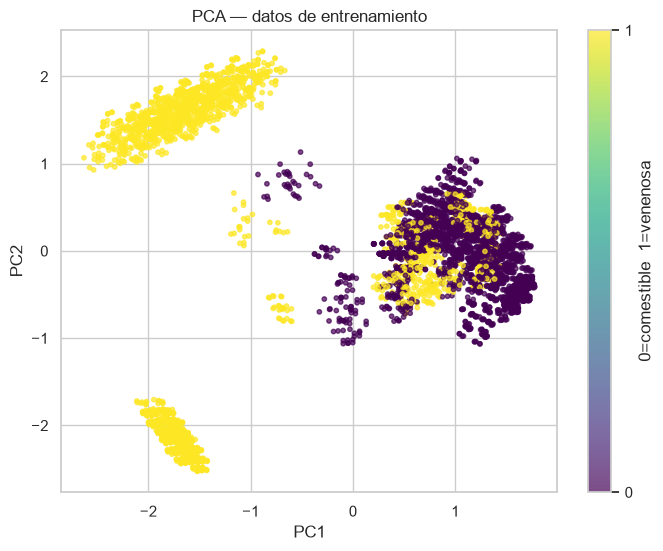

In [7]:
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca = pca2.fit_transform(X_train)
y_train_num = y_train.map({'e': 0, 'p': 1})

plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train_num, cmap='viridis', s=10, alpha=0.7)
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('PCA — datos de entrenamiento')
plt.colorbar(ticks=[0, 1], label='0=comestible  1=venenosa')
plt.show()

## 5. Línea base supervisada — Random Forest

In [8]:
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
print(f"Accuracy (todas las features): {accuracy_score(y_test, rf.predict(X_test)):.4f}")

Accuracy (todas las features): 1.0000


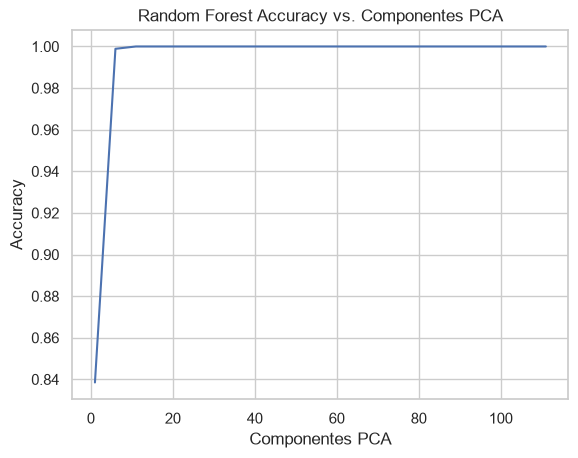

In [9]:
# ¿Cuántas componentes PCA bastan para mantener la precisión?
n_features = range(1, X_train.shape[1] + 1, 5)
scores = []
for n in n_features:
    pca_n = PCA(n_components=n, random_state=RANDOM_STATE)
    Xtr = pca_n.fit_transform(X_train)
    Xte = pca_n.transform(X_test)
    rf_n = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
    rf_n.fit(Xtr, y_train)
    scores.append(rf_n.score(Xte, y_test))

sns.lineplot(x=list(n_features), y=scores)
plt.xlabel('Componentes PCA'); plt.ylabel('Accuracy')
plt.title('Random Forest Accuracy vs. Componentes PCA')
plt.grid(True); plt.show()

## 6. t-SNE — reducción no lineal

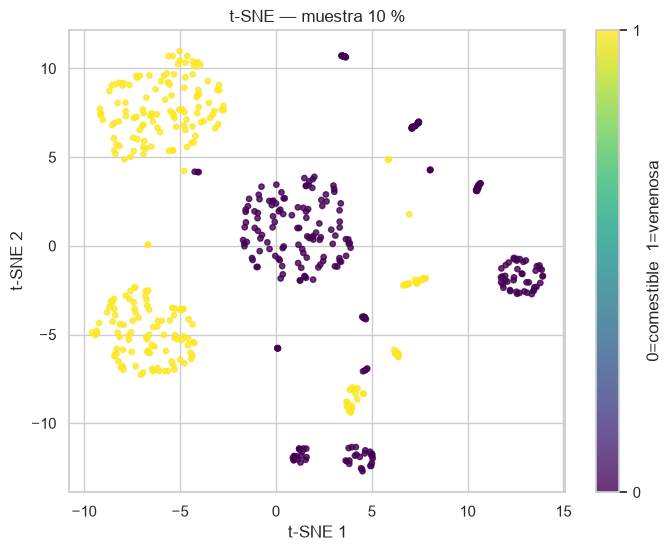

In [10]:
X_sample = X_train.sample(frac=0.1, random_state=RANDOM_STATE)
y_sample = y_train.loc[X_sample.index].map({'e': 0, 'p': 1})

tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, max_iter=300)
X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sample, cmap='viridis', s=15, alpha=0.8)
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2')
plt.title('t-SNE — muestra 10 %')
plt.colorbar(ticks=[0, 1], label='0=comestible  1=venenosa')
plt.show()

## 7. Clustering — preparación (PCA 10 componentes)

In [11]:
pca10 = PCA(n_components=10, random_state=RANDOM_STATE)
X_red = pca10.fit_transform(X)

## 8. K-Means — codo + silhouette

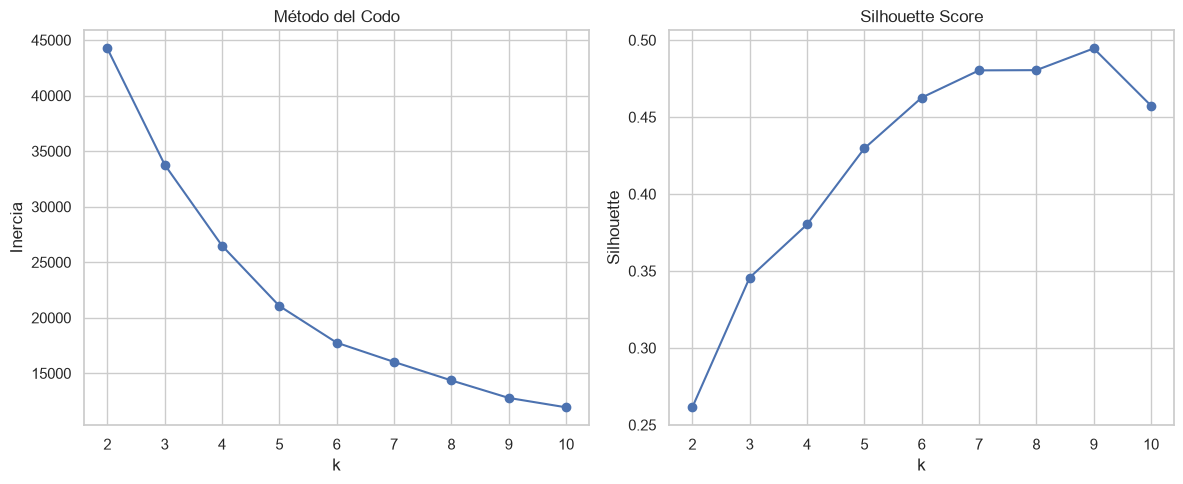

In [12]:
k_values = range(2, 11)
inercias, silhouettes = [], []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_red)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_red, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(k_values, inercias, marker='o')
axes[0].set(xlabel='k', ylabel='Inercia', title='Método del Codo')
axes[1].plot(k_values, silhouettes, marker='o')
axes[1].set(xlabel='k', ylabel='Silhouette', title='Silhouette Score')
plt.tight_layout(); plt.show()

## 9. K-Means final (k=2) y comparación con etiqueta

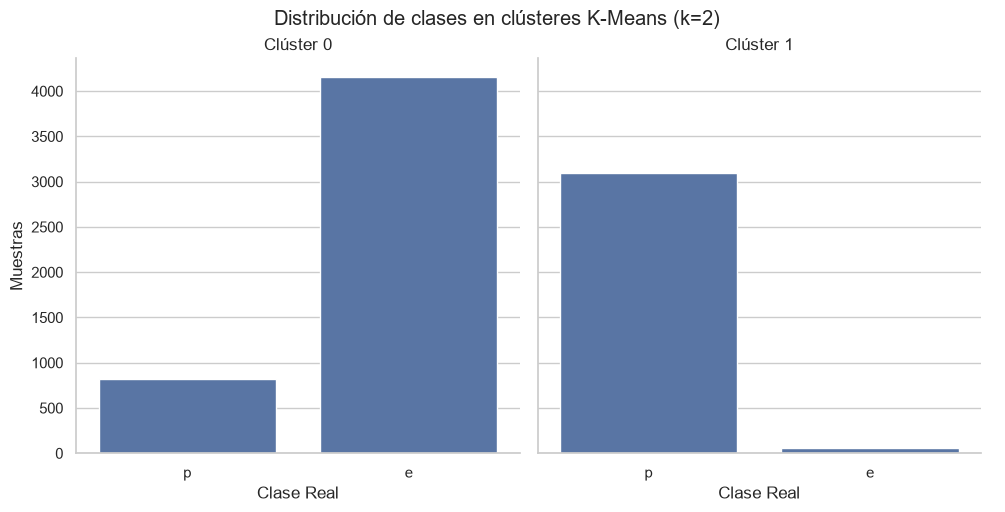

ARI: 0.6171  |  NMI: 0.5663


In [13]:
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
kmeans.fit(X_red)

results_df = pd.DataFrame({'Cluster': kmeans.labels_, 'Class': y})
ax = sns.catplot(col='Cluster', x='Class', data=results_df, kind='count', col_wrap=2)
ax.set_axis_labels('Clase Real', 'Muestras')
ax.set_titles('Clúster {col_name}')
plt.suptitle('Distribución de clases en clústeres K-Means (k=2)', y=1.02)
plt.show()

ari = adjusted_rand_score(y, kmeans.labels_)
nmi = normalized_mutual_info_score(y, kmeans.labels_)
print(f"ARI: {ari:.4f}  |  NMI: {nmi:.4f}")

## 10. Comparativa de algoritmos

In [14]:
def evaluar(nombre, labels, X_data, y_true):
    n_cl = len(set(labels)) - (1 if -1 in labels else 0)
    mask = labels != -1
    sil = db = ch = np.nan
    if n_cl >= 2 and mask.sum() >= 2:
        try:
            sil = silhouette_score(X_data[mask], labels[mask])
            db  = davies_bouldin_score(X_data[mask], labels[mask])
            ch  = calinski_harabasz_score(X_data[mask], labels[mask])
        except ValueError:
            pass
    return {
        'Algoritmo': nombre, 'N_Clusters': n_cl,
        'Silhouette': round(sil, 4) if not np.isnan(sil) else np.nan,
        'Davies-Bouldin': round(db, 4) if not np.isnan(db) else np.nan,
        'Calinski-Harabasz': round(ch, 2) if not np.isnan(ch) else np.nan,
        'ARI': round(adjusted_rand_score(y_true, labels), 4),
        'NMI': round(normalized_mutual_info_score(y_true, labels), 4)
    }

results = []
results.append(evaluar('KMeans (k=2)', kmeans.labels_, X_red, y))

agg = AgglomerativeClustering(n_clusters=2)
results.append(evaluar('Aglomerativo (k=2)', agg.fit_predict(X_red), X_red, y))

gmm = GaussianMixture(n_components=2, random_state=RANDOM_STATE)
results.append(evaluar('GMM (k=2)', gmm.fit_predict(X_red), X_red, y))

dbscan = DBSCAN(eps=1.5, min_samples=5)
results.append(evaluar('DBSCAN', dbscan.fit_predict(X_red), X_red, y))

display(pd.DataFrame(results))

,Algoritmo,N_Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI
0,KMeans (k=2),2,0.2614,1.6929,2564.69,0.6171,0.5663
1,Aglomerativo (k=2),2,0.2589,1.6963,2503.62,0.6090,0.5936
2,GMM (k=2),2,0.2579,1.7009,2500.02,0.5986,0.5657
3,DBSCAN,6,0.3580,1.0708,2304.34,0.3736,0.4638


## 11. Dendrograma (clustering jerárquico)

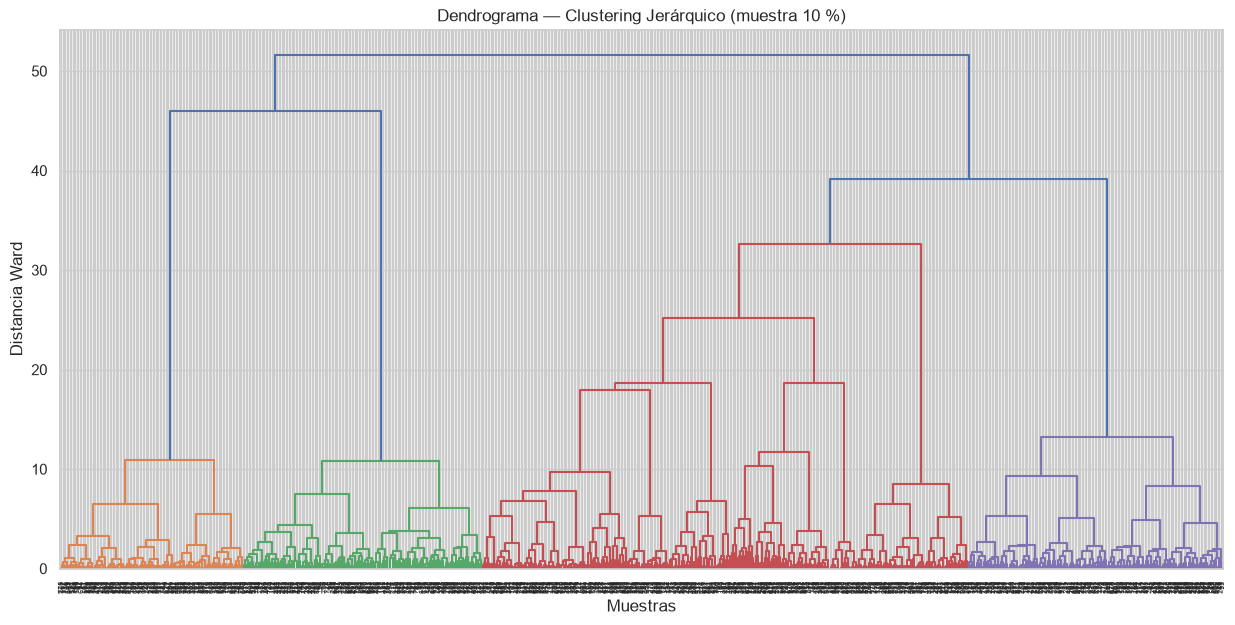

In [15]:
np.random.seed(RANDOM_STATE)
idx = np.random.choice(X_red.shape[0], int(0.1 * X_red.shape[0]), replace=False)
linked = linkage(X_red[idx], method='ward')

plt.figure(figsize=(15, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Dendrograma — Clustering Jerárquico (muestra 10 %)')
plt.xlabel('Muestras'); plt.ylabel('Distancia Ward')
plt.show()

## 12. DBSCAN: euclídea vs Jaccard

In [16]:
X_bin = X.astype(int)

res_dbscan = []
lbl_euc = DBSCAN(eps=1.5, min_samples=5, metric='euclidean').fit_predict(X_red)
res_dbscan.append(evaluar('DBSCAN Euclidean (X_red)', lbl_euc, X_red, y))

lbl_jac = DBSCAN(eps=0.5, min_samples=5, metric='jaccard').fit_predict(X_bin)
res_dbscan.append(evaluar('DBSCAN Jaccard (X_bin)', lbl_jac, X_bin, y))

display(pd.DataFrame(res_dbscan))

c:\Users\Coder\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\pairwise.py:2462: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


,Algoritmo,N_Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI
0,DBSCAN Euclidean (X_red),6,0.3580,1.0708,2304.34,0.3736,0.4638
1,DBSCAN Jaccard (X_bin),3,0.1073,1.3465,138.19,-0.0007,0.0455


**Lección:** con datos categóricos one-hot, Jaccard captura mejor la similitud binaria que la distancia euclídea.

## 13. Visualización final: clusters vs etiqueta real

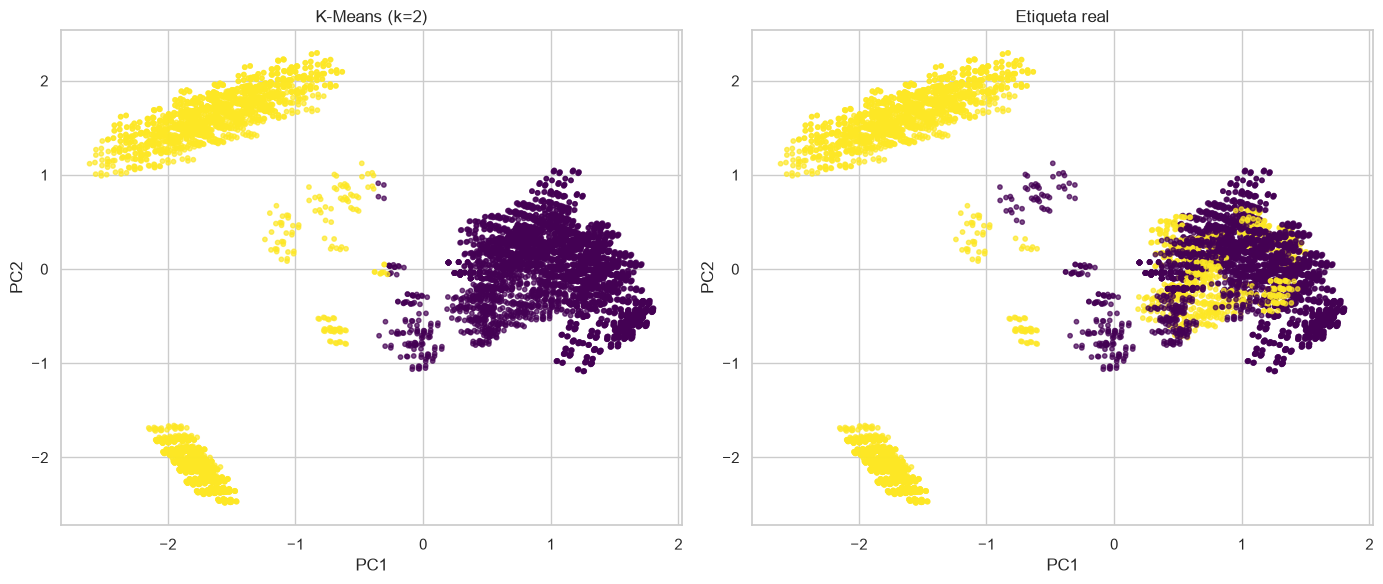

In [17]:
pca_vis = PCA(n_components=2, random_state=RANDOM_STATE)
X_vis = pca_vis.fit_transform(X)
y_num = y.map({'e': 0, 'p': 1})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(X_vis[:, 0], X_vis[:, 1], c=kmeans.labels_, cmap='viridis', s=10, alpha=0.7)
axes[0].set(title='K-Means (k=2)', xlabel='PC1', ylabel='PC2')

axes[1].scatter(X_vis[:, 0], X_vis[:, 1], c=y_num, cmap='viridis', s=10, alpha=0.7)
axes[1].set(title='Etiqueta real', xlabel='PC1', ylabel='PC2')

plt.tight_layout(); plt.show()

## 14. Detección de anomalías — Isolation Forest

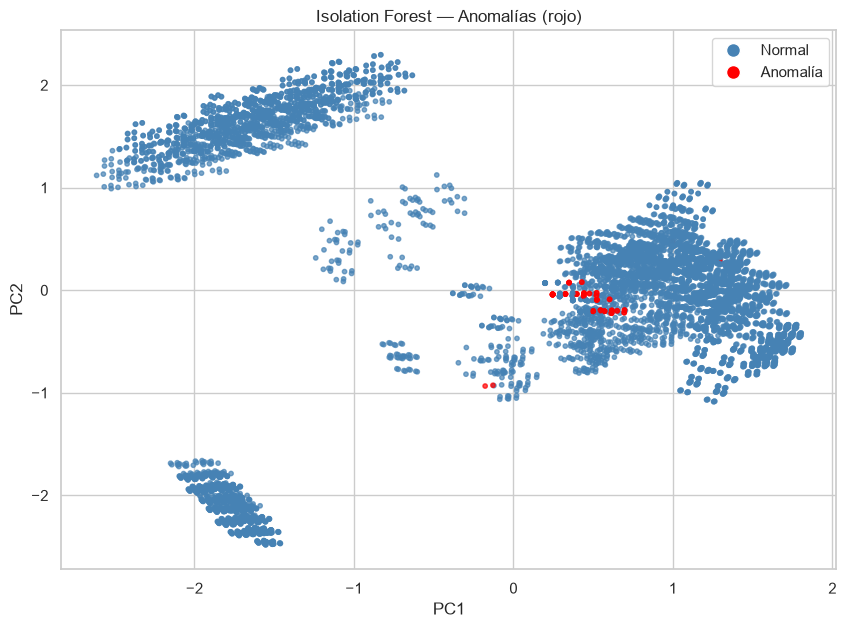

Anomalías detectadas: 82


In [18]:
iso = IsolationForest(contamination=0.01, random_state=RANDOM_STATE)
preds = iso.fit_predict(X_red)

colors = np.where(preds == 1, 'steelblue', 'red')
plt.figure(figsize=(10, 7))
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=colors, s=10, alpha=0.7)
plt.title('Isolation Forest — Anomalías (rojo)')
plt.xlabel('PC1'); plt.ylabel('PC2')
legend_els = [Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', markersize=10, label='Normal'),
              Line2D([0],[0], marker='o', color='w', markerfacecolor='red',      markersize=10, label='Anomalía')]
plt.legend(handles=legend_els)
plt.show()
print(f"Anomalías detectadas: {(preds == -1).sum()}")

## Conclusiones

- PCA y t-SNE permiten visualizar un dataset de >100 dimensiones en 2D.
- K-Means, GMM y Aglomerativo recuperan la estructura comestible/venenosa con ARI notable **sin usar la etiqueta**.
- DBSCAN con distancia Jaccard supera a la euclídea en datos categóricos one-hot.
- Isolation Forest localiza las setas más atípicas.
- **No hay un algoritmo que gane siempre**: el acierto está en elegir el preprocesado, la distancia y la métrica de validación según el tipo de datos.